<a href="https://colab.research.google.com/github/parulgoell/ai-attendance-agent/blob/main/waste_segregation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classification Accuracy: 0.3333333333333333


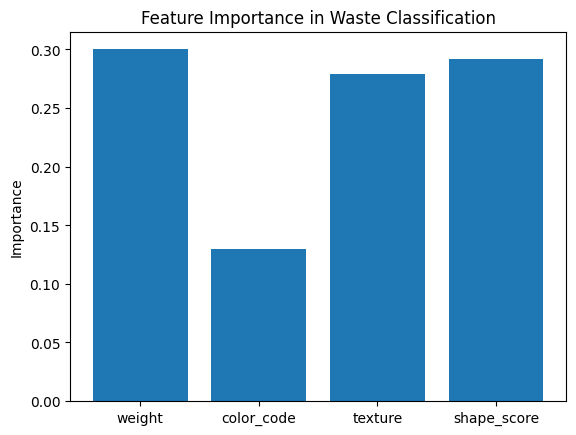

In [ ]:
# --- Waste Segregation AI : Single Cell Code ---

# Install required libraries silently (-q = quiet)
!pip install scikit-learn numpy pandas -q

# Import necessary libraries
import numpy as np                     # For numerical operations
import pandas as pd                    # For creating and managing datasets
from sklearn.model_selection import train_test_split   # For splitting data
from sklearn.ensemble import RandomForestClassifier    # ML classifier model
import matplotlib.pyplot as plt        # For plotting graph (added import)

# -----------------------------
# 1. Create Synthetic Dataset
# -----------------------------

np.random.seed(0)   # Ensures same random values every run (reproducibility)

# Creating synthetic dataset with random values
data = {
    "weight": np.random.uniform(10, 200, 120),    # Random weight between 10–200 grams
    "color_code": np.random.randint(0, 5, 120),   # Random color category (0–4)
    "texture": np.random.uniform(0, 1, 120),      # Random texture score
    "shape_score": np.random.uniform(0, 1, 120),  # Random shape uniform/irregular score
    "label": np.random.choice(                   # Randomly assign waste type labels
        ["Organic", "Plastic", "Metal", "Paper", "Glass"],
        120
    )
}

df = pd.DataFrame(data)   # Convert dictionary into a DataFrame table

# Select input features (X)
X = df[["weight", "color_code", "texture", "shape_score"]]

# Select target label (y)
y = df["label"]

# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0   # random_state fixes split order
)

# -----------------------------
# 2. Train ML Classifier Agent
# -----------------------------

classifier_agent = RandomForestClassifier(   # Initialize Random Forest model
    n_estimators=100,                        # Use 100 decision trees
    random_state=0                           # Ensure reproducibility
)

classifier_agent.fit(X_train, y_train)       # Train the model using training data

# -----------------------------
# 3. Output Classification Accuracy
# -----------------------------

accuracy = classifier_agent.score(X_test, y_test)  # Compute accuracy on test data
print("Classification Accuracy:", accuracy)         # Print accuracy value

# -----------------------------
# 4. Plot Feature Importance
# -----------------------------

plt.bar(X.columns, classifier_agent.feature_importances_)  # Bar graph of feature importance
plt.title("Feature Importance in Waste Classification")     # Graph title
plt.ylabel("Importance")                                    # Y-axis label
plt.show()                                                  # Display the plot
